In [5]:
#make sure to set the scenario in drivers.py to your selected scenario (SSP2) is the only option right now. 
# set the scenario to the correct ones in the other pre-processing files as well (lifetime, materials, capacity) to ensure that the correct data is used for the model.

from pathlib import Path
import prism
import pandas as pd
import numpy as np
import xarray as xr
import scipy
import matplotlib.pyplot as plt

YEAR_START = 1971   # start year of the simulation period
YEAR_END = 2100     # end year of the calculations
YEAR_OUT = 2100     # year of output generation = last year of reporting
year_end = 2100     # end year of the calculations
year_out = 2100
year_start = 1971 

from imagematerials.model import GenericStocks, MaterialIntensities, SharesInflowStocks
from imagematerials.factory import ModelFactory, Sector
from imagematerials.preprocessing import get_preprocessing_data
from imagematerials.fossil_fuels.preprocessing.ffconstants import (path_base,STANDARD_SCEN_EXTERNAL_DATA)

#define path base or current path?

circular_economy_config = None
climate_policy_config = "SSP2_baseline" #SSP2_baseline is the only option right now given the existing files of primpersec and final_energy_rt
scenario = "SSP2_baseline" #SSP2_baseline is the only option right now given the existing files of primpersec and final_energy_rt


In [6]:
from imagematerials.fossil_fuels.preprocessing.ffconstants import REGIONS_TIMER

In [7]:
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_extraction
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_processing
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_transport
from imagematerials.fossil_fuels.preprocessing.main import get_preprocessing_data_pipelines

In [8]:

scenario_list = {"SSP2_baseline":("SSP2_baseline", None),
                 }


time_start = 1971
complete_timeline = prism.Timeline(time_start, YEAR_END, 1)
simulation_timeline = prism.Timeline(YEAR_START, YEAR_END, 1)

all_output = {}

for scen_id, (climate_scen, circular_scen) in scenario_list.items():
    climate_policy_scenario_dir = Path(path_base, "data", "raw", "image", climate_scen)
    circular_economy_scenario_dir = None 
    scenario = path_base /"fossil_fuels"/ STANDARD_SCEN_EXTERNAL_DATA


    sec_ff = get_preprocessing_data("fossil_fuels", path_base,
                                        climate_policy_scenario_dir, 
                                        circular_economy_scenario_dir, cache = False) 
    # ff_sector is a list of preprocessing data for each fossil fuel subsector

    factory = ModelFactory(
    sec_ff, complete_timeline
    ).add(GenericStocks, ["ff_extr",
                         "ff_proc",
                         "ff_trp",
                         "ff_pipe"
                          ]
    ).add(MaterialIntensities, ["ff_extr",
                         "ff_proc",
                         "ff_trp",
                         "ff_pipe"
                          ]
    )
    model = factory.finish()

    model.simulate(simulation_timeline)
    all_output[scen_id] = model
    print(f"Finished {scen_id}")



Finished SSP2_baseline


In [9]:
all_output["SSP2_baseline"].ff_extr.keys()

dict_keys(['lifetimes', 'stocks', 'material_intensities', 'knowledge_graph', 'set_unit_flexible', 'outflow_by_cohort', 'inflow', 'stock_by_cohort', 'stock_by_cohort_materials', 'inflow_materials', 'outflow_by_cohort_materials'])

In [72]:
# All output to array to see dimensions and sometimes to plot because the key returned by the model is an xarray dataset.
# all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array()
all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"]
all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"]
# all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"]
# all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"]
# all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(Region= "CAN",material = "steel").sum(dim = "Type").plot()
# all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(Region= "USA",material = "aluminium").sum(dim = "Type").plot()
# all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(Region=1,material = "steel").sum(dim = "Type").plot()


<xarray.DataArray (Time: 130, Region: 26, Type: 4, material: 3)> Size: 324kB
<Quantity([[[[6.48801605e+02 0.00000000e+00 0.00000000e+00]
   [3.23546958e+06 0.00000000e+00 0.00000000e+00]
   [2.41894460e+06 0.00000000e+00 0.00000000e+00]
   [1.50492518e+08 0.00000000e+00 1.09240762e+07]]

  [[1.28621223e+04 0.00000000e+00 0.00000000e+00]
   [5.44564482e+07 0.00000000e+00 0.00000000e+00]
   [2.23674196e+07 0.00000000e+00 0.00000000e+00]
   [1.52634888e+09 0.00000000e+00 1.10795883e+08]]

  [[5.86782840e+01 0.00000000e+00 0.00000000e+00]
   [1.09435479e+06 0.00000000e+00 0.00000000e+00]
   [7.10784090e+05 0.00000000e+00 0.00000000e+00]
   [4.73062231e+07 0.00000000e+00 3.43390350e+06]]

  ...

  [[9.00850069e+02 0.00000000e+00 0.00000000e+00]
   [3.26598270e+05 0.00000000e+00 0.00000000e+00]
   [9.21489170e+05 0.00000000e+00 0.00000000e+00]
...
   [7.05954371e+06 0.00000000e+00 0.00000000e+00]
   [2.49669332e+06 0.00000000e+00 0.00000000e+00]
   [1.66167381e+08 0.00000000e+00 1.20618962e+07]]

  ...

  [[1.63883760e+02 0.00000000e+00 0.00000000e+00]
   [7.52151409e+06 0.00000000e+00 0.00000000e+00]
   [7.89111315e+05 0.00000000e+00 0.00000000e+00]
   [5.53824498e+07 0.00000000e+00 4.02014737e+06]]

  [[1.31486294e+04 0.00000000e+00 0.00000000e+00]
   [8.00452772e+07 0.00000000e+00 0.00000000e+00]
   [8.61491593e+06 0.00000000e+00 0.00000000e+00]
   [6.19337240e+08 0.00000000e+00 4.49569672e+07]]

  [[7.65441168e+02 0.00000000e+00 0.00000000e+00]
   [2.16096456e+07 0.00000000e+00 0.00000000e+00]
   [5.89857642e+06 0.00000000e+00 0.00000000e+00]
   [4.32862124e+08 0.00000000e+00 3.14209562e+07]]]], 'kilogram')>
Coordinates:
  * Time      (Time) int64 1kB 1971 1972 1973 1974 1975 ... 2097 2098 2099 2100
  * Region    (Region) <U5 520B 'CAN' 'USA' 'MEX' 'RCAM' ... 'OCE' 'RSAS' 'RSAF'
  * Type      (Type) <U16 256B 'Coal Preparation' ... 'Oil Storage'
  * material  (material) <U9 108B 'steel' 'copper' 'aluminium'

In [ ]:
# you can also save the steps in between in a variable to avoid repeating the same things, for example:
# save the model output of a specific scenario
# SSP2_baseline_scenario = all_output["SSP2_baseline"]
# save a certain variable
# gen_inflow_global = model_scenario_x.elc_gen["inflow"].to_array().sum(["Region"])

# #To change a unit do this:
# var = model_scenario_x.elc_gen["inflow_materials"].to_array().pint.to("megaton")

# # If you automatically want to have the correct unit printed in a figure you can do:
unit = "megaton"
# var = model_scenario_x.elc_gen["inflow_materials"].to_array().pint.to(unit)

# fig, ax = plt.subplots(figsize=(8,6))

# plt.ylabel(f"material inflow ({unit})", fontsize=14)


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Time
2019    1258.879157
2050    1358.846946
dtype: float64


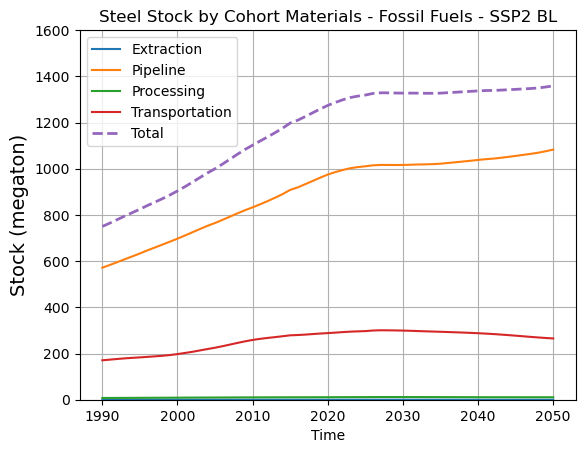

In [53]:
#the key for the stock by cohort materials is already in xarray format, so we can directly select the material and region and plot it.

#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="steel").sel(Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")
plt.title("Steel Stock by Cohort Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Stock ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0, 1600) 

plt.legend()

print(total.sel(Time=[2019, 2050]).to_series())

Time
2019    0.894154
2050    0.837015
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


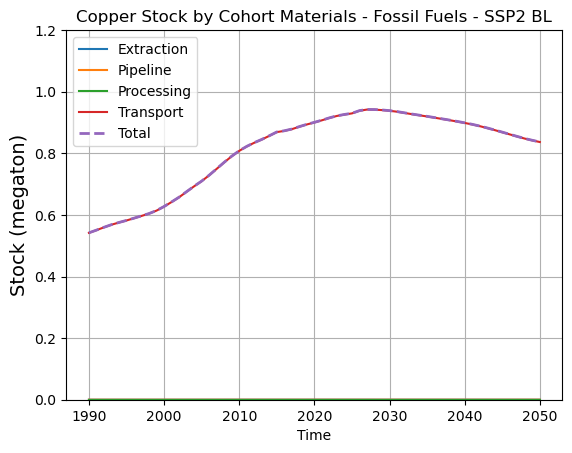

In [54]:
# plot for copper in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material = "copper").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
extr.plot(label="Extraction")
pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material = "copper").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
pipe.plot(label="Pipeline")
proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material = "copper").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
proc.plot(label="Processing")
trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material = "copper").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
trp.plot(label="Transport")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Copper Stock by Cohort Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Stock ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0, 1.2) 

print(total.sel(Time=[2019, 2050]).to_series())


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


Time
2019    11.055095
2050    10.493118
dtype: float64


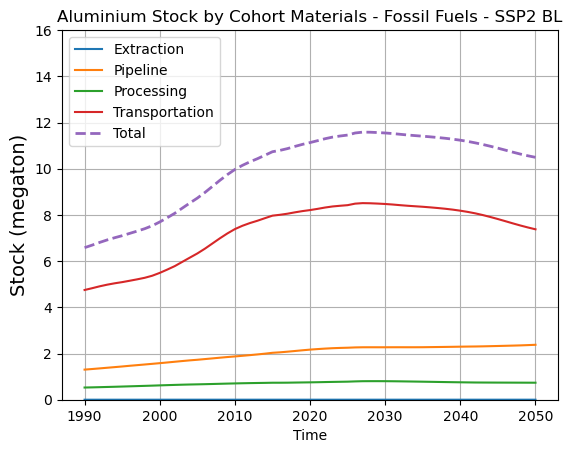

In [55]:
# plot for aluminium in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material = "aluminium").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
extr.plot(label="Extraction")
pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material = "aluminium").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
pipe.plot(label="Pipeline")
proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material = "aluminium").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
proc.plot(label="Processing")
trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material = "aluminium").sel(Time=slice(1990, 2050)).sum(dim = "Type").sum(dim = "Region").pint.to("megaton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Aluminium Stock by Cohort Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Stock ({unit})", fontsize=14)
plt.grid(True)
plt.legend()
plt.ylim(0, 16) 

print(total.sel(Time=[2019, 2050]).to_series())


In [30]:
# # plot for aluminium in all regions and types for each sector plotted on the same graph to compare the sectors.
# all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Extraction")
# all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Pipeline")
# all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Processing")
# all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material = "aluminium", Region = "USA").sum(dim = "Type").plot(label="Transportation")

# plt.legend()

/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


time
2019    23.310647
2050    30.811440
dtype: float64


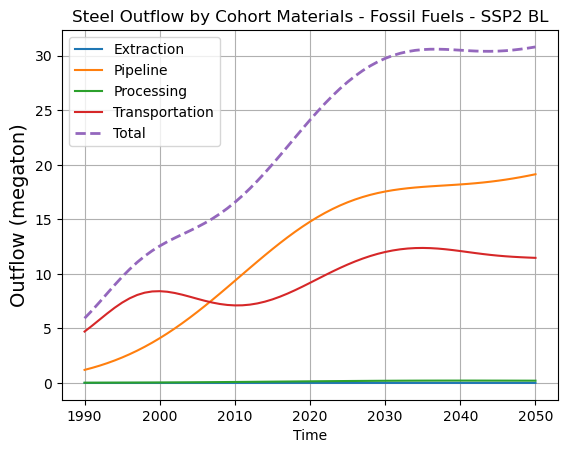

In [60]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
# extr = all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
# extr.plot(label="Extraction")

# pipe = all_output["SSP2_baseline"].ff_pipe["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
# pipe.plot(label="Pipeline")

# proc = all_output["SSP2_baseline"].ff_proc["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
# proc.plot(label="Processing")

# trp = all_output["SSP2_baseline"].ff_trp["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1980, 2100)).sum(dim="Type").sum(dim="Region")
# trp.plot(label="Transportation")

extr = all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["outflow_by_cohort_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Steel Outflow by Cohort Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Outflow ({unit})", fontsize=14)
plt.legend()
plt.grid(True)

print(total.sel(time=[2019, 2050]).to_series())
# print(extr.dims)

/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


time
2019    30.156478
2050    37.935704
dtype: float64


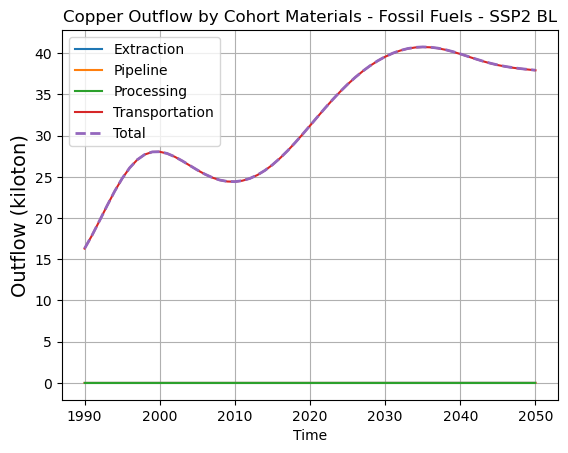

In [61]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["outflow_by_cohort_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["outflow_by_cohort_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["outflow_by_cohort_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Copper Outflow by Cohort Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "kiloton"
plt.ylabel(f"Outflow ({unit})", fontsize=14)
plt.legend()
plt.grid(True)

print(total.sel(time=[2019, 2050]).to_series())



/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


time
2019    288.972791
2050    378.319358
dtype: float64


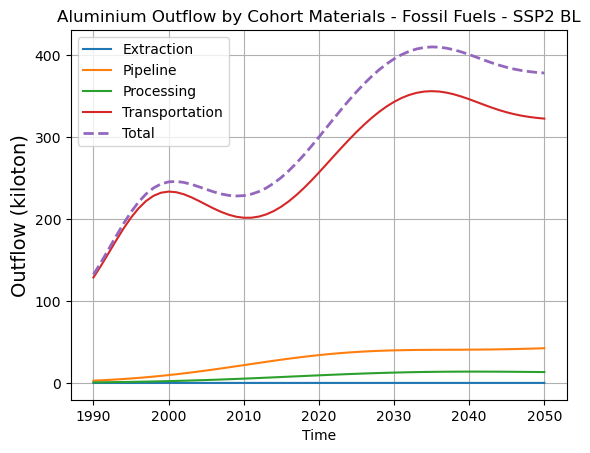

In [62]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["outflow_by_cohort_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Aluminium Outflow by Cohort Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "kiloton"
plt.ylabel(f"Outflow ({unit})", fontsize=14)
plt.legend()
plt.grid(True)

print(total.sel(time=[2019, 2050]).to_series())

# plt.legend()

/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


time
2019    39.865628
2050    35.871851
dtype: float64


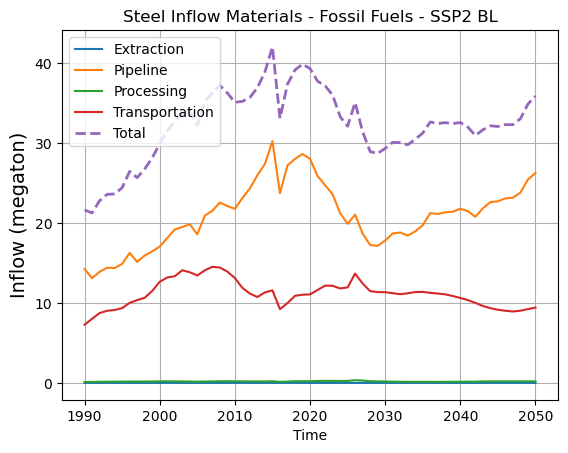

In [57]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["inflow_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["inflow_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["inflow_materials"].to_array().sel(material="steel").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Steel Inflow Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Inflow ({unit})", fontsize=14)
plt.legend()
plt.grid(True)

print(total.sel(time=[2019, 2050]).to_series())
# plt.legend()

/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


time
2019    37.536387
2050    32.700329
dtype: float64


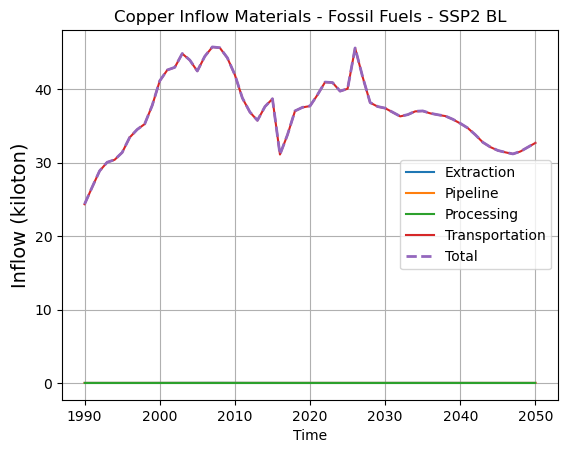

In [58]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["inflow_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["inflow_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["inflow_materials"].to_array().sel(material="copper").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")


plt.title("Copper Inflow Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "kiloton"
plt.ylabel(f"Inflow ({unit})", fontsize=14)
plt.legend()
plt.grid(True)

print(total.sel(time=[2019, 2050]).to_series())
# plt.legend()

time
2019    377.542384
2050    312.247808
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


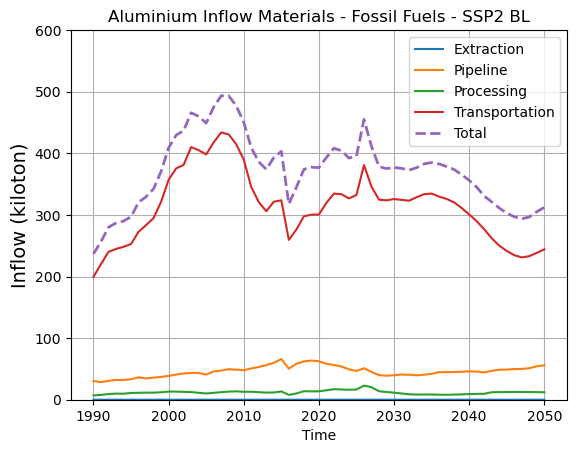

In [59]:
#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
extr = all_output["SSP2_baseline"].ff_extr["inflow_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
extr.plot(label="Extraction")

pipe = all_output["SSP2_baseline"].ff_pipe["inflow_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
pipe.plot(label="Pipeline")

proc = all_output["SSP2_baseline"].ff_proc["inflow_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
proc.plot(label="Processing")

trp = all_output["SSP2_baseline"].ff_trp["inflow_materials"].to_array().sel(material="aluminium").sel(time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("kiloton")
trp.plot(label="Transportation")

# Sum of all
total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Aluminium Inflow Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "kiloton"
plt.ylabel(f"Inflow ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0,600)

# plt.legend()
print(total.sel(time=[2019, 2050]).to_series())

In [ ]:

coal_extraction_types = ["Coal Opencast", "Coal Underground"]
coal_processing_types = ["Coal Preparation"]
coal_transport_types = ["Coal Inland Ship", "Coal Ocean Ship", "Coal Rail", "Coal Truck"]

gas_extraction_types = ["Gas Offshore", "Gas Onshore"]
gas_processing_types = ["Gas Processing"]
gas_transport_types = ["Gas Inland Ship", "Gas Ocean Ship", "Gas Rail", "Gas Truck"]
gas_pipeline_types = ["Gas Distribution Pipeline", "Gas Transmission Pipeline"] 

oil_extraction_types = ["Oil Offshore", "Oil Onshore"]
oil_transport_types = ["Oil Inland Ship", "Oil Ocean Ship", "Oil Rail", "Oil Truck"]
oil_pipeline_types = ["Oil Onshore Crude Pipeline", "Oil Onshore Product Pipeline", "Oil Offshore Crude Pipeline", "Oil Offshore Product Pipeline"] 
oil_processing_types = ["Oil Refinery", "Oil Storage"]


#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="steel", Type=gas_extraction_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"] .sel(material="steel", Type=gas_pipeline_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="steel", Type=gas_processing_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="steel", Type=gas_transport_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"] .sel(material="steel", Type=oil_extraction_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="steel", Type=oil_pipeline_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"] .sel(material="steel", Type=oil_processing_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="steel", Type=oil_transport_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="steel", Type=coal_extraction_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="steel", Type=coal_processing_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="steel", Type=coal_transport_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")


# Sum of all
gas_total = gas_extr + gas_pipe + gas_proc + gas_trp
coal_total = coal_extr + coal_proc + coal_trp
oil_total  = oil_extr + oil_pipe + oil_proc + oil_trp

print(gas_total.sel(Time=[2019, 2050]).to_series())
print(coal_total.sel(Time=[2019, 2050]).to_series())
print(oil_total.sel(Time=[2019, 2050]).to_series())


Time
2019    778.804726
2050    904.899695
dtype: float64
Time
2019    148.270366
2050    126.918428
dtype: float64
Time
2019    331.804064
2050    327.028823
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [82]:

coal_extraction_types = ["Coal Opencast", "Coal Underground"]
coal_processing_types = ["Coal Preparation"]
coal_transport_types = ["Coal Inland Ship", "Coal Ocean Ship", "Coal Rail", "Coal Truck"]

gas_extraction_types = ["Gas Offshore", "Gas Onshore"]
gas_processing_types = ["Gas Processing"]
gas_transport_types = ["Gas Inland Ship", "Gas Ocean Ship", "Gas Rail", "Gas Truck"]
gas_pipeline_types = ["Gas Distribution Pipeline", "Gas Transmission Pipeline"] 

oil_extraction_types = ["Oil Offshore", "Oil Onshore"]
oil_transport_types = ["Oil Inland Ship", "Oil Ocean Ship", "Oil Rail", "Oil Truck"]
oil_pipeline_types = ["Oil Onshore Crude Pipeline", "Oil Onshore Product Pipeline", "Oil Offshore Crude Pipeline", "Oil Offshore Product Pipeline"] 
oil_processing_types = ["Oil Refinery", "Oil Storage"]


#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="copper", Type=gas_extraction_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"] .sel(material="copper", Type=gas_pipeline_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="copper", Type=gas_processing_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="copper", Type=gas_transport_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"] .sel(material="copper", Type=oil_extraction_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="copper", Type=oil_pipeline_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"] .sel(material="copper", Type=oil_processing_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="copper", Type=oil_transport_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="copper", Type=coal_extraction_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="copper", Type=coal_processing_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="copper", Type=coal_transport_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")


# Sum of all
gas_total = gas_extr + gas_pipe + gas_proc + gas_trp
coal_total = coal_extr + coal_proc + coal_trp
oil_total  = oil_extr + oil_pipe + oil_proc + oil_trp

print(gas_total.sel(Time=[2019, 2050]).to_series())
print(coal_total.sel(Time=[2019, 2050]).to_series())
print(oil_total.sel(Time=[2019, 2050]).to_series())

Time
2019    0.095163
2050    0.110211
dtype: float64
Time
2019    0.398493
2050    0.340953
dtype: float64
Time
2019    0.400499
2050    0.385851
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [ ]:

coal_extraction_types = ["Coal Opencast", "Coal Underground"]
coal_processing_types = ["Coal Preparation"]
coal_transport_types = ["Coal Inland Ship", "Coal Ocean Ship", "Coal Rail", "Coal Truck"]

gas_extraction_types = ["Gas Offshore", "Gas Onshore"]
gas_processing_types = ["Gas Processing"]
gas_transport_types = ["Gas Inland Ship", "Gas Ocean Ship", "Gas Rail", "Gas Truck"]
gas_pipeline_types = ["Gas Distribution Pipeline", "Gas Transmission Pipeline"] 

oil_extraction_types = ["Oil Offshore", "Oil Onshore"]
oil_transport_types = ["Oil Inland Ship", "Oil Ocean Ship", "Oil Rail", "Oil Truck"]
oil_pipeline_types = ["Oil Onshore Crude Pipeline", "Oil Onshore Product Pipeline", "Oil Offshore Crude Pipeline", "Oil Offshore Product Pipeline"] 
oil_processing_types = ["Oil Refinery", "Oil Storage"]


#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="aluminium", Type=gas_extraction_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"] .sel(material="aluminium", Type=gas_pipeline_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="aluminium", Type=gas_processing_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="aluminium", Type=gas_transport_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"] .sel(material="aluminium", Type=oil_extraction_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="aluminium", Type=oil_pipeline_types, Time=[2019, 2050]).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"] .sel(material="aluminium", Type=oil_processing_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="aluminium", Type=oil_transport_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="aluminium", Type=coal_extraction_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="aluminium", Type=coal_processing_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="aluminium", Type=coal_transport_types, Time=[2019, 2050]) .sum(dim="Type").sum(dim="Region").pint.to("megaton")


# Sum of all
gas_total = gas_extr + gas_pipe + gas_proc + gas_trp
coal_total = coal_extr + coal_proc + coal_trp
oil_total  = oil_extr + oil_pipe + oil_proc + oil_trp

print(gas_total.sel(Time=[2019, 2050]).to_series())
print(coal_total.sel(Time=[2019, 2050]).to_series())
print(oil_total.sel(Time=[2019, 2050]).to_series())

total = extr + pipe + proc + trp
total.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Aluminium Inflow Materials - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "kiloton"
plt.ylabel(f"Inflow ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0,600)

Time
2019    1.847681
2050    2.145633
dtype: float64
Time
2019    5.220285
2050    4.467680
dtype: float64
Time
2019    3.987129
2050    3.879806
dtype: float64


/Applications/anaconda3/envs/imagepy312_dev/lib/python3.12/site-packages/xarray/core/variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


(0.0, 15.0)

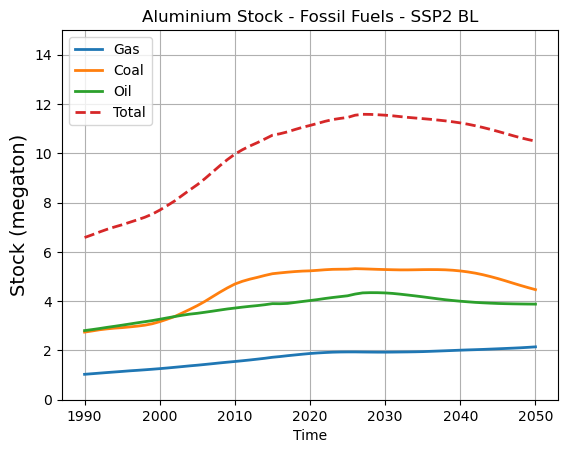

In [13]:

coal_extraction_types = ["Coal Opencast", "Coal Underground"]
coal_processing_types = ["Coal Preparation"]
coal_transport_types = ["Coal Inland Ship", "Coal Ocean Ship", "Coal Rail", "Coal Truck"]

gas_extraction_types = ["Gas Offshore", "Gas Onshore"]
gas_processing_types = ["Gas Processing"]
gas_transport_types = ["Gas Inland Ship", "Gas Ocean Ship", "Gas Rail", "Gas Truck"]
gas_pipeline_types = ["Gas Distribution Pipeline", "Gas Transmission Pipeline"] 

oil_extraction_types = ["Oil Offshore", "Oil Onshore"]
oil_transport_types = ["Oil Inland Ship", "Oil Ocean Ship", "Oil Rail", "Oil Truck"]
oil_pipeline_types = ["Oil Onshore Crude Pipeline", "Oil Onshore Product Pipeline", "Oil Offshore Crude Pipeline", "Oil Offshore Product Pipeline"] 
oil_processing_types = ["Oil Refinery", "Oil Storage"]


#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="aluminium", Type=gas_extraction_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"] .sel(material="aluminium", Type=gas_pipeline_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="aluminium", Type=gas_processing_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
gas_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="aluminium", Type=gas_transport_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"] .sel(material="aluminium", Type=oil_extraction_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="aluminium", Type=oil_pipeline_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
oil_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"] .sel(material="aluminium", Type=oil_processing_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="aluminium", Type=oil_transport_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")
coal_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="aluminium", Type=coal_extraction_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="aluminium", Type=coal_processing_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="aluminium", Type=coal_transport_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")


# Sum of all
gas_total = gas_extr + gas_pipe + gas_proc + gas_trp
coal_total = coal_extr + coal_proc + coal_trp
oil_total = oil_extr + oil_pipe + oil_proc + oil_trp
total_overall = gas_total + coal_total + oil_total

gas_total.plot(label="Gas", linewidth=2, linestyle="-")
coal_total.plot(label="Coal", linewidth=2, linestyle="-")
oil_total.plot(label="Oil", linewidth=2, linestyle="-")
total_overall.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Aluminium Stock - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Stock ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0,15)


(0.0, 1.2)

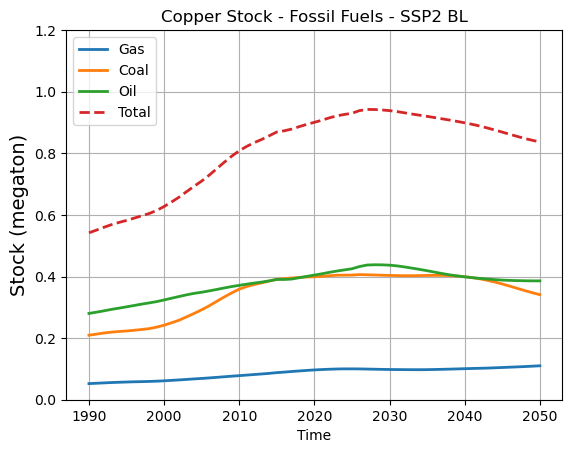

In [15]:
coal_extraction_types = ["Coal Opencast", "Coal Underground"]
coal_processing_types = ["Coal Preparation"]
coal_transport_types = ["Coal Inland Ship", "Coal Ocean Ship", "Coal Rail", "Coal Truck"]

gas_extraction_types = ["Gas Offshore", "Gas Onshore"]
gas_processing_types = ["Gas Processing"]
gas_transport_types = ["Gas Inland Ship", "Gas Ocean Ship", "Gas Rail", "Gas Truck"]
gas_pipeline_types = ["Gas Distribution Pipeline", "Gas Transmission Pipeline"] 

oil_extraction_types = ["Oil Offshore", "Oil Onshore"]
oil_transport_types = ["Oil Inland Ship", "Oil Ocean Ship", "Oil Rail", "Oil Truck"]
oil_pipeline_types = ["Oil Onshore Crude Pipeline", "Oil Onshore Product Pipeline", "Oil Offshore Crude Pipeline", "Oil Offshore Product Pipeline"] 
oil_processing_types = ["Oil Refinery", "Oil Storage"]


#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="copper", Type=gas_extraction_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"] .sel(material="copper", Type=gas_pipeline_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="copper", Type=gas_processing_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
gas_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="copper", Type=gas_transport_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"] .sel(material="copper", Type=oil_extraction_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="copper", Type=oil_pipeline_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
oil_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"] .sel(material="copper", Type=oil_processing_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="copper", Type=oil_transport_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")
coal_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="copper", Type=coal_extraction_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="copper", Type=coal_processing_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="copper", Type=coal_transport_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")


# Sum of all
gas_total = gas_extr + gas_pipe + gas_proc + gas_trp
coal_total = coal_extr + coal_proc + coal_trp
oil_total = oil_extr + oil_pipe + oil_proc + oil_trp
total_overall = gas_total + coal_total + oil_total

gas_total.plot(label="Gas", linewidth=2, linestyle="-")
coal_total.plot(label="Coal", linewidth=2, linestyle="-")
oil_total.plot(label="Oil", linewidth=2, linestyle="-")
total_overall.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Copper Stock - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Stock ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0,1.2)


(0.0, 1600.0)

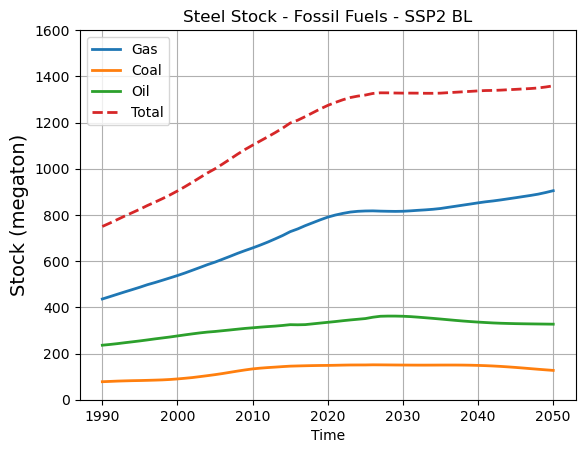

In [18]:
coal_extraction_types = ["Coal Opencast", "Coal Underground"]
coal_processing_types = ["Coal Preparation"]
coal_transport_types = ["Coal Inland Ship", "Coal Ocean Ship", "Coal Rail", "Coal Truck"]

gas_extraction_types = ["Gas Offshore", "Gas Onshore"]
gas_processing_types = ["Gas Processing"]
gas_transport_types = ["Gas Inland Ship", "Gas Ocean Ship", "Gas Rail", "Gas Truck"]
gas_pipeline_types = ["Gas Distribution Pipeline", "Gas Transmission Pipeline"] 

oil_extraction_types = ["Oil Offshore", "Oil Onshore"]
oil_transport_types = ["Oil Inland Ship", "Oil Ocean Ship", "Oil Rail", "Oil Truck"]
oil_pipeline_types = ["Oil Onshore Crude Pipeline", "Oil Onshore Product Pipeline", "Oil Offshore Crude Pipeline", "Oil Offshore Product Pipeline"] 
oil_processing_types = ["Oil Refinery", "Oil Storage"]


#plot for steel in all regions and types for each sector plotted on the same graph to compare the sectors.
gas_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="steel", Type=gas_extraction_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"] .sel(material="steel", Type=gas_pipeline_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

gas_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="steel", Type=gas_processing_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
gas_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"].sel(material="steel", Type=gas_transport_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"] .sel(material="steel", Type=oil_extraction_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_pipe = all_output["SSP2_baseline"].ff_pipe["stock_by_cohort_materials"].sel(material="steel", Type=oil_pipeline_types, Time=slice(1990, 2050)).sum(dim="Type").sum(dim="Region").pint.to("megaton")
oil_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"] .sel(material="steel", Type=oil_processing_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

oil_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="steel", Type=oil_transport_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")
coal_extr = all_output["SSP2_baseline"].ff_extr["stock_by_cohort_materials"].sel(material="steel", Type=coal_extraction_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_proc = all_output["SSP2_baseline"].ff_proc["stock_by_cohort_materials"].sel(material="steel", Type=coal_processing_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")

coal_trp = all_output["SSP2_baseline"].ff_trp["stock_by_cohort_materials"] .sel(material="steel", Type=coal_transport_types, Time=slice(1990, 2050)) .sum(dim="Type").sum(dim="Region").pint.to("megaton")


# Sum of all
gas_total = gas_extr + gas_pipe + gas_proc + gas_trp
coal_total = coal_extr + coal_proc + coal_trp
oil_total = oil_extr + oil_pipe + oil_proc + oil_trp
total_overall = gas_total + coal_total + oil_total

gas_total.plot(label="Gas", linewidth=2, linestyle="-")
coal_total.plot(label="Coal", linewidth=2, linestyle="-")
oil_total.plot(label="Oil", linewidth=2, linestyle="-")
total_overall.plot(label="Total", linewidth=2, linestyle="--")

plt.title("Steel Stock - Fossil Fuels - SSP2 BL")
plt.xlabel("Time")
unit = "megaton"
plt.ylabel(f"Stock ({unit})", fontsize=14)
plt.legend()
plt.grid(True)
plt.ylim(0,1600)